# sklearn model with tensorflow keras tuner

In [ ]:
# ! python -m pip install --no-index --find-links=/kaggle/usr/lib/pip_install_permanent/my_packages -r /kaggle/usr/lib/pip_install_permanent/requirements.txt

In [ ]:
# import os
# os.environ['PACKAGE_DIR'] = '/kaggle/usr/lib/pip_install_permanent'

In [1]:
import sklearn
print(sklearn.__version__)

1.2.2


In [2]:
from helper_func import *
# # import helper_functions as hf
# import sys
# import nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# import string
# from spellchecker import SpellChecker
# from textblob import TextBlob
# from multiprocessing import Pool
# from tqdm import tqdm
# import numpy as np
# import pandas as pd
# # Preprocessing
# from nltk.tokenize import word_tokenize, sent_tokenize
# import operator
# from spellchecker import SpellChecker
# from tqdm import tqdm  # Import tqdm
# import re
# import inflect
# from wordsegment import load, segment
# from nltk.corpus import words
# word_list = set(words.words())
# from spellchecker import SpellChecker

# from tqdm.contrib.concurrent import process_map  # If this import fails, you might need to update tqdm

# import multiprocessing
 
# # Import Packages
# # import shutup; shutup.please()
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import tensorflow as tf
# import keras_tuner as kt
# import seaborn as sns

# from nltk.corpus import stopwords, wordnet
# from nltk.tokenize import word_tokenize, sent_tokenize
# from nltk import pos_tag, ne_chunk
# from textblob import TextBlob

# from textstat import flesch_reading_ease, smog_index

# import spacy
# from collections import Counter
# from gensim import corpora, models
# import pyLDAvis.gensim as gen
# import pyLDAvis
# import re

# # Machine Learning & Data Preprocessing

# from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

# # Deep Learning

# from tensorflow.keras import layers
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences

# # Gensim
# # from gensim.models import Word2Vec, KeyedVectors
# import pandas as pd
# # Progress bar
# from tqdm import tqdm

# # Keras Tuner
# from keras_tuner.tuners import RandomSearch

# # # Setting logging levels and environment variables
# # tf.get_logger().setLevel(logging.ERROR)
# # os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# from textstat import flesch_reading_ease

# # from helper_functions import *
# import nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# import string
# from spellchecker import SpellChecker
# from textblob import TextBlob
# from multiprocessing import Pool
# from tqdm import tqdm
# import numpy as np
# import pandas as pd
# # Preprocessing
# from nltk.tokenize import word_tokenize, sent_tokenize
# import operator
# from spellchecker import SpellChecker
# from tqdm import tqdm  # Import tqdm
# import re
# import inflect
# from wordsegment import load, segment
# from nltk.corpus import words
# word_list = set(words.words())
# print('Packages Instaled......')
import sklearn
print(sklearn.__version__)

1.2.2


[nltk_data] Downloading package punkt to /home/jack/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/jack/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [3]:
import sklearn
print(sklearn.__version__)

1.2.2


In [4]:
import pandas as pd

deberta_train = pd.read_csv('/home/jack/github/kaggle/scoring/deberta_train_predictions.csv')
deberta_val = pd.read_csv('/home/jack/github/kaggle/scoring/deberta_val_predictions.csv')

In [5]:
deberta_full = pd.concat([deberta_train, deberta_val])

In [6]:
deberta_full.drop(columns=['clean_text', 'score'], inplace=True)

In [7]:
train = pd.read_csv('/home/jack/github/kaggle/scoring/data/train.csv')

In [8]:
print(deberta_full.shape, train.shape)

(17307, 7) (17307, 3)


In [9]:
# Combine train and deberta_full on essay_id

train = train.merge(deberta_full, on='essay_id')

In [10]:
train.to_parquet('train_with_deberta.parquet')

In [11]:
import os
from tqdm import tqdm

glove_path = 'data/glove-840B-300d.txt'

paragram_path = '/home/jack/github/kaggle/scoring/data/paragram-300-sl999.txt'

wiki_news_path = 'data/wiki-news-1M-300d.vec'


# Load embeddings

embeddings = parallel_load_embeddings([glove_path, paragram_path, wiki_news_path])

glove = embeddings["glove"]
paragram = embeddings["paragram"]
fasttext = embeddings["fasttext"]

[nltk_data] Downloading package punkt to /home/jack/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/jack/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
Reading Embedding File: 0it [00:00, ?it/s][nltk_data] Downloading package punkt to /home/jack/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/jack/nltk_data...

Loading embeddings from data/glove-840B-300d.txt
Loading embeddings from data/wiki-news-1M-300d.vec
Loading embeddings from /home/jack/github/kaggle/scoring/data/paragram-300-sl999.txt


Reading Embedding File: 999995it [00:35, 28375.66it/s]]
Reading Embedding File: 1016312it [00:35, 25886.69it/s]

Loaded embeddings from data/wiki-news-1M-300d.vec


Reading Embedding File: 1703756it [00:59, 28423.07it/s]
Reading Embedding File: 1749011it [01:00, 30408.18it/s]

Loaded embeddings from /home/jack/github/kaggle/scoring/data/paragram-300-sl999.txt


Reading Embedding File: 2196017it [01:14, 29287.66it/s]


Loaded embeddings from data/glove-840B-300d.txt


In [12]:
train, oov_glove, oov_paragram, oov_fasttxt = spellcheck_and_correct_text(train, embeddings)

Starting text cleaning process. 

Checking Vocabulary................. 

Processing dataset.
Building vocabulary.


Populating Vocabulary: 100%|██████████| 17307/17307 [00:00<00:00, 22048.13it/s]


Vocabulary built.
Checking coverage.


Checking Words: 100%|██████████| 65918/65918 [00:00<00:00, 1462486.41it/s]


Coverage checked.
Checking coverage.


Checking Words: 100%|██████████| 65918/65918 [00:00<00:00, 1615737.37it/s]


Coverage checked.
Checking coverage.


Checking Words: 100%|██████████| 65918/65918 [00:00<00:00, 1701039.35it/s]


Coverage checked.
Processed dataset.
Adding Text Features................. 

Complete................. 



In [13]:
def custom_train_validation_split(essays, test_size=0.2, random_state=56):
    
    """
    Custom function to perform train-validation split ensuring that
    the same prompt IDs are in both training and validation sets.

    Parameters:
    - summaries: DataFrame containing summaries and associated prompt_ids
    - prompts: DataFrame containing prompts and associated prompt_ids
    - test_size: Proportion of the dataset to be used as the validation set
    - random_state: Random seed for reproducibility

    Returns:
    - train_summaries: Training set containing summaries
    - validation_summaries: Validation set containing summaries
    - train_prompts: Training set containing prompts
    - validation_prompts: Validation set containing prompts
    """

    from sklearn.model_selection import train_test_split

    
    # Extract unique prompt IDs
    unique_essay_ids = essays['essay_id'].unique()

    # Split the unique prompt IDs into training and validation sets
    train_ids, validation_ids = train_test_split(unique_essay_ids, test_size=test_size, random_state=random_state)

    # Use these IDs to filter the original summaries and prompts DataFrames
    train_essays = essays[essays['essay_id'].isin(train_ids)]
    validation_essays = essays[essays['essay_id'].isin(validation_ids)]

    return train_essays, validation_essays

In [14]:

train_essays, val_essays = custom_train_validation_split(train, test_size=0.25, random_state=42)

In [15]:
train_essays.head()

,essay_id,full_text,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,lowered,...,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score
1,000fe60,I am a scientist at NASA that is discussing th...,3,0.015906,0.832160,0.148738,0.002510,0.000311,0.000375,i am a scientist at nasa that is discussing th...,...,335,335.0,335,335,3.868657,11,1,-234.72,134.48,0.7050
2,001ab80,People always wish they had the same technolog...,4,0.001099,0.010704,0.344778,0.631197,0.011407,0.000815,people always wish they had the same technolog...,...,551,551.0,551,551,4.464610,15,1,-470.88,222.72,-0.7712
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,0.052828,0.680586,0.248129,0.016296,0.001250,0.000911,"dear, state senator\n\nthis is a letter to arg...",...,383,383.0,383,383,4.676240,13,1,-308.82,155.71,0.9836
6,0033037,The posibilty of a face reconizing computer wo...,2,0.110127,0.875541,0.012530,0.000799,0.000427,0.000577,the posibilty of a face reconizing computer wo...,...,179,179.0,179,179,4.670391,13,1,-93.30,74.51,-0.1566
7,0033bf4,What is the Seagoing Cowboys progam?\n\nIt was...,3,0.004650,0.469768,0.515730,0.009045,0.000419,0.000389,what is the seagoing cowboys progam?\n\nit was...,...,354,354.0,354,354,4.423729,14,1,-262.46,142.39,0.9960


In [16]:
# import pandas as pd

# train_essays = pd.read_parquet('/home/jack/github/kaggle/scoring/train_essays.parquet')
# val_essays = pd.read_parquet('/home/jack/github/kaggle/scoring/validation_essays.parquet')

In [17]:
pd.set_option('display.max_columns', None)

train_essays.head()

,essay_id,full_text,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,lowered,clean_text,combined_dense_vector,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_vec_158,dense_vec_159,dense_vec_160,dense_vec_161,dense_vec_162,dense_vec_163,dense_vec_164,dense_vec_165,dense_vec_166,dense_vec_167,dense_vec_168,dense_vec_169,dense_vec_170,dense_vec_171,dense_vec_172,dense_vec_173,dense_vec_174,dense_vec_175,dense_vec_176,dense_vec_177,dense_vec_178,dense_vec_179,dense_vec_180,dense_vec_181,dense_vec_182,dense_vec_183,dense_vec_184,dense_vec_185,dense_vec_186,dense_vec_187,dense_vec_188,dense_vec_189,dense_vec_190,dense_vec_191,dense_vec_192,dense_vec_193,dense_vec_194,dense_vec_195,dense_vec_196,dense_vec_197,dense_vec_198,dense_vec_199,dense_vec_200,dense_vec_201,dense_vec_202,dense_vec_203,dense_vec_204,dense_vec_205,dense_vec_206,dense_vec_207,dense_vec_208,dense_vec_209,dense_vec_210,dense_vec_211,dense_vec_212,dense_vec_213,dense_vec_214,dense_vec_215,dense_vec_216,dense_vec_217,dense_vec_218,dense_vec_219,dense_vec_220,dense_vec_221,dense_vec_222,dense_vec_223,dense_vec_224,dense_vec_225,dense_vec_226,dense_vec_227,dense_vec_228,dense_vec_229,dense_vec_230,dense_vec_231,dense_vec_232,dense_vec_233,dense_vec_234,dense_vec_235,dense_vec_236,dense_vec_237,dense_vec_238,dense_vec_239,dense_vec_240,dense_vec_241,dense_vec_242,dense_vec_243,dense_vec_244,dense_vec_245,dense_vec_246,dense_vec_247,dense_vec_248,dense_vec_249,dense_vec_250,dense_vec_251,dense_vec_252,dense_vec_253,dense_vec_254,dense_vec_255,dense_vec_256,dense_vec_257,dense_vec_258,dense_vec_259,dense_vec_260,dense_vec_261,dense_vec_262,dense_vec_263,dense_vec_264,dense_vec_265,dense_vec_266,dense_vec_267,dense_vec_268,dense_vec_269,dense_vec_270,dense_vec_271,dense_vec_272,dense_vec_273,dense_vec_274,dense_vec_275,dense_vec_276,dense_vec_277,dense_vec_278,dense_vec_279,dense_vec_280,dense_vec_281,dense

In [18]:
train_essays['score'].value_counts()

score
3    4706
2    3517
4    2988
1     926
5     731
6     112
Name: count, dtype: int64

In [91]:
drop_cols = [ 'full_text', 'lowered', 'clean_text', 'combined_dense_vector']


train_df = train_essays.copy()
val_df = val_essays.copy()

train_df.drop(columns=drop_cols, inplace= True)
val_df.drop(columns=drop_cols, inplace= True)


In [92]:
train_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_vec_158,dense_vec_159,dense_vec_160,dense_vec_161,dense_vec_162,dense_vec_163,dense_vec_164,dense_vec_165,dense_vec_166,dense_vec_167,dense_vec_168,dense_vec_169,dense_vec_170,dense_vec_171,dense_vec_172,dense_vec_173,dense_vec_174,dense_vec_175,dense_vec_176,dense_vec_177,dense_vec_178,dense_vec_179,dense_vec_180,dense_vec_181,dense_vec_182,dense_vec_183,dense_vec_184,dense_vec_185,dense_vec_186,dense_vec_187,dense_vec_188,dense_vec_189,dense_vec_190,dense_vec_191,dense_vec_192,dense_vec_193,dense_vec_194,dense_vec_195,dense_vec_196,dense_vec_197,dense_vec_198,dense_vec_199,dense_vec_200,dense_vec_201,dense_vec_202,dense_vec_203,dense_vec_204,dense_vec_205,dense_vec_206,dense_vec_207,dense_vec_208,dense_vec_209,dense_vec_210,dense_vec_211,dense_vec_212,dense_vec_213,dense_vec_214,dense_vec_215,dense_vec_216,dense_vec_217,dense_vec_218,dense_vec_219,dense_vec_220,dense_vec_221,dense_vec_222,dense_vec_223,dense_vec_224,dense_vec_225,dense_vec_226,dense_vec_227,dense_vec_228,dense_vec_229,dense_vec_230,dense_vec_231,dense_vec_232,dense_vec_233,dense_vec_234,dense_vec_235,dense_vec_236,dense_vec_237,dense_vec_238,dense_vec_239,dense_vec_240,dense_vec_241,dense_vec_242,dense_vec_243,dense_vec_244,dense_vec_245,dense_vec_246,dense_vec_247,dense_vec_248,dense_vec_249,dense_vec_250,dense_vec_251,dense_vec_252,dense_vec_253,dense_vec_254,dense_vec_255,dense_vec_256,dense_vec_257,dense_vec_258,dense_vec_259,dense_vec_260,dense_vec_261,dense_vec_262,dense_vec_263,dense_vec_264,dense_vec_265,dense_vec_266,dense_vec_267,dense_vec_268,dense_vec_269,dense_vec_270,dense_vec_271,dense_vec_272,dense_vec_273,dense_vec_274,dense_vec_275,dense_vec_276,dense_vec_277,dense_vec_278,dense_vec_279,dense_vec_280,dense_vec_281,dense_vec_282,dense_vec_283,dense_vec_284,dense_vec_285,

In [93]:
feature_cols = []

for col in train_df.columns:
    if (col != 'essay_id') and (col != 'score'):
        feature_cols.append(col) 

In [94]:
pd.set_option('display.max_columns', None)
feature_cols

['deberta_prob_0',
 'deberta_prob_1',
 'deberta_prob_2',
 'deberta_prob_3',
 'deberta_prob_4',
 'deberta_prob_5',
 'dense_vec_0',
 'dense_vec_1',
 'dense_vec_2',
 'dense_vec_3',
 'dense_vec_4',
 'dense_vec_5',
 'dense_vec_6',
 'dense_vec_7',
 'dense_vec_8',
 'dense_vec_9',
 'dense_vec_10',
 'dense_vec_11',
 'dense_vec_12',
 'dense_vec_13',
 'dense_vec_14',
 'dense_vec_15',
 'dense_vec_16',
 'dense_vec_17',
 'dense_vec_18',
 'dense_vec_19',
 'dense_vec_20',
 'dense_vec_21',
 'dense_vec_22',
 'dense_vec_23',
 'dense_vec_24',
 'dense_vec_25',
 'dense_vec_26',
 'dense_vec_27',
 'dense_vec_28',
 'dense_vec_29',
 'dense_vec_30',
 'dense_vec_31',
 'dense_vec_32',
 'dense_vec_33',
 'dense_vec_34',
 'dense_vec_35',
 'dense_vec_36',
 'dense_vec_37',
 'dense_vec_38',
 'dense_vec_39',
 'dense_vec_40',
 'dense_vec_41',
 'dense_vec_42',
 'dense_vec_43',
 'dense_vec_44',
 'dense_vec_45',
 'dense_vec_46',
 'dense_vec_47',
 'dense_vec_48',
 'dense_vec_49',
 'dense_vec_50',
 'dense_vec_51',
 'dense_vec_

In [95]:
# !pip install scikit-learn==1.2.2

In [96]:
import sklearn
print(sklearn.__version__)

1.2.2


In [97]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import numpy as np

# Extract labels from the training and validation datasets
train_labels = train_df['score']  # Extracts 'score' column as the label
val_labels = val_df['score']

# Extract features for scaling
train_features = train_df[feature_cols] # Subset with only feature columns
val_features = val_df[feature_cols]

# Initialize the scaler
scaler = MinMaxScaler()  # Using StandardScaler for scaling

# Fit the scaler to the training features
scaler.fit(train_features)  # This defines the transformation based on the training data

# Transform training and validation features
train_feats_scaled = scaler.transform(train_features)  # Transforms the training data
val_feats_scaled = scaler.transform(val_features)  # Transforms the validation data

# Reassign the scaled features to the original DataFrames, keeping the same column names
train_df[feature_cols] = train_feats_scaled  # Replace the original features with scaled ones
val_df[feature_cols] = val_feats_scaled

# Save the scaler for later use
with open('sklearn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)  # Persist the scaler for future use or reference


In [98]:
# Check if the file has been written correctly and is not empty
import os
scaler_path = 'sklearn_scaler.pkl'
if os.path.getsize(scaler_path) > 0:
    print(f"Scaler saved successfully in {scaler_path}.")
else:
    print(f"Failed to save scaler to {scaler_path}. File is empty.")

Scaler saved successfully in sklearn_scaler.pkl.


In [99]:
# Check if the scaler is StandardScaler
if isinstance(scaler, StandardScaler):
    print("The scaler is a StandardScaler.")
elif isinstance(scaler, MinMaxScaler):
    print("The scaler is a MinMaxScaler.")
else:
    print("The scaler is neither StandardScaler nor MinMaxScaler.")

The scaler is a MinMaxScaler.


In [100]:
# train_df = pca_dataframe(train_df)
# val_df = pca_dataframe(val_df)

In [101]:
train_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_vec_158,dense_vec_159,dense_vec_160,dense_vec_161,dense_vec_162,dense_vec_163,dense_vec_164,dense_vec_165,dense_vec_166,dense_vec_167,dense_vec_168,dense_vec_169,dense_vec_170,dense_vec_171,dense_vec_172,dense_vec_173,dense_vec_174,dense_vec_175,dense_vec_176,dense_vec_177,dense_vec_178,dense_vec_179,dense_vec_180,dense_vec_181,dense_vec_182,dense_vec_183,dense_vec_184,dense_vec_185,dense_vec_186,dense_vec_187,dense_vec_188,dense_vec_189,dense_vec_190,dense_vec_191,dense_vec_192,dense_vec_193,dense_vec_194,dense_vec_195,dense_vec_196,dense_vec_197,dense_vec_198,dense_vec_199,dense_vec_200,dense_vec_201,dense_vec_202,dense_vec_203,dense_vec_204,dense_vec_205,dense_vec_206,dense_vec_207,dense_vec_208,dense_vec_209,dense_vec_210,dense_vec_211,dense_vec_212,dense_vec_213,dense_vec_214,dense_vec_215,dense_vec_216,dense_vec_217,dense_vec_218,dense_vec_219,dense_vec_220,dense_vec_221,dense_vec_222,dense_vec_223,dense_vec_224,dense_vec_225,dense_vec_226,dense_vec_227,dense_vec_228,dense_vec_229,dense_vec_230,dense_vec_231,dense_vec_232,dense_vec_233,dense_vec_234,dense_vec_235,dense_vec_236,dense_vec_237,dense_vec_238,dense_vec_239,dense_vec_240,dense_vec_241,dense_vec_242,dense_vec_243,dense_vec_244,dense_vec_245,dense_vec_246,dense_vec_247,dense_vec_248,dense_vec_249,dense_vec_250,dense_vec_251,dense_vec_252,dense_vec_253,dense_vec_254,dense_vec_255,dense_vec_256,dense_vec_257,dense_vec_258,dense_vec_259,dense_vec_260,dense_vec_261,dense_vec_262,dense_vec_263,dense_vec_264,dense_vec_265,dense_vec_266,dense_vec_267,dense_vec_268,dense_vec_269,dense_vec_270,dense_vec_271,dense_vec_272,dense_vec_273,dense_vec_274,dense_vec_275,dense_vec_276,dense_vec_277,dense_vec_278,dense_vec_279,dense_vec_280,dense_vec_281,dense_vec_282,dense_vec_283,dense_vec_284,dense_vec_285,

In [102]:
val_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_vec_158,dense_vec_159,dense_vec_160,dense_vec_161,dense_vec_162,dense_vec_163,dense_vec_164,dense_vec_165,dense_vec_166,dense_vec_167,dense_vec_168,dense_vec_169,dense_vec_170,dense_vec_171,dense_vec_172,dense_vec_173,dense_vec_174,dense_vec_175,dense_vec_176,dense_vec_177,dense_vec_178,dense_vec_179,dense_vec_180,dense_vec_181,dense_vec_182,dense_vec_183,dense_vec_184,dense_vec_185,dense_vec_186,dense_vec_187,dense_vec_188,dense_vec_189,dense_vec_190,dense_vec_191,dense_vec_192,dense_vec_193,dense_vec_194,dense_vec_195,dense_vec_196,dense_vec_197,dense_vec_198,dense_vec_199,dense_vec_200,dense_vec_201,dense_vec_202,dense_vec_203,dense_vec_204,dense_vec_205,dense_vec_206,dense_vec_207,dense_vec_208,dense_vec_209,dense_vec_210,dense_vec_211,dense_vec_212,dense_vec_213,dense_vec_214,dense_vec_215,dense_vec_216,dense_vec_217,dense_vec_218,dense_vec_219,dense_vec_220,dense_vec_221,dense_vec_222,dense_vec_223,dense_vec_224,dense_vec_225,dense_vec_226,dense_vec_227,dense_vec_228,dense_vec_229,dense_vec_230,dense_vec_231,dense_vec_232,dense_vec_233,dense_vec_234,dense_vec_235,dense_vec_236,dense_vec_237,dense_vec_238,dense_vec_239,dense_vec_240,dense_vec_241,dense_vec_242,dense_vec_243,dense_vec_244,dense_vec_245,dense_vec_246,dense_vec_247,dense_vec_248,dense_vec_249,dense_vec_250,dense_vec_251,dense_vec_252,dense_vec_253,dense_vec_254,dense_vec_255,dense_vec_256,dense_vec_257,dense_vec_258,dense_vec_259,dense_vec_260,dense_vec_261,dense_vec_262,dense_vec_263,dense_vec_264,dense_vec_265,dense_vec_266,dense_vec_267,dense_vec_268,dense_vec_269,dense_vec_270,dense_vec_271,dense_vec_272,dense_vec_273,dense_vec_274,dense_vec_275,dense_vec_276,dense_vec_277,dense_vec_278,dense_vec_279,dense_vec_280,dense_vec_281,dense_vec_282,dense_vec_283,dense_vec_284,dense_vec_285,

In [103]:
# train_df.to_parquet('train_df.parquet')
# val_df.to_parquet('val_df.parquet')

In [104]:
import pandas as pd
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

df = train_df.copy()
# Downsample majority classes to 1,000 samples
target_samples = 1000
balanced_df = pd.DataFrame()

for class_label in df['score'].unique():
    class_subset = df[df['score'] == class_label]
    
    if len(class_subset) > target_samples:
        # Downsample to 1,000 samples for majority classes
        class_subset = resample(
            class_subset,
            replace=False,
            n_samples=target_samples,
            random_state=42
        )
    
    balanced_df = pd.concat([balanced_df, class_subset], axis=0)

# Now, let's apply SMOTE to balance the minority classes up to 1,000 samples
X = balanced_df.drop(columns = ['essay_id','score'], axis=1)
y = balanced_df['score']

# Create SMOTE instance to ensure all classes have 1,000 samples
smote = SMOTE(sampling_strategy={k: 1000 for k in y.unique()}, random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

# Create the resampled DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['score'] = y_resampled

# Display the resampled class distribution to confirm the balancing
print("Resampled class distribution:")
print(df_resampled['score'].value_counts())


Resampled class distribution:
score
3    1000
4    1000
2    1000
1    1000
5    1000
6    1000
Name: count, dtype: int64


/tmp/ipykernel_19479/557032744.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_resampled['score'] = y_resampled


In [105]:
UPSAMPLE = True

if UPSAMPLE:
    
    # Balance only the training DataFrame
    train_df = df_resampled.copy()

    
else:
    pass

print(train_df['score'].value_counts())
print(val_df['score'].value_counts())

score
3    1000
4    1000
2    1000
1    1000
5    1000
6    1000
Name: count, dtype: int64
score
3    1574
2    1206
4     938
1     326
5     239
6      44
Name: count, dtype: int64


In [107]:
train_df.head()

,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_vec_158,dense_vec_159,dense_vec_160,dense_vec_161,dense_vec_162,dense_vec_163,dense_vec_164,dense_vec_165,dense_vec_166,dense_vec_167,dense_vec_168,dense_vec_169,dense_vec_170,dense_vec_171,dense_vec_172,dense_vec_173,dense_vec_174,dense_vec_175,dense_vec_176,dense_vec_177,dense_vec_178,dense_vec_179,dense_vec_180,dense_vec_181,dense_vec_182,dense_vec_183,dense_vec_184,dense_vec_185,dense_vec_186,dense_vec_187,dense_vec_188,dense_vec_189,dense_vec_190,dense_vec_191,dense_vec_192,dense_vec_193,dense_vec_194,dense_vec_195,dense_vec_196,dense_vec_197,dense_vec_198,dense_vec_199,dense_vec_200,dense_vec_201,dense_vec_202,dense_vec_203,dense_vec_204,dense_vec_205,dense_vec_206,dense_vec_207,dense_vec_208,dense_vec_209,dense_vec_210,dense_vec_211,dense_vec_212,dense_vec_213,dense_vec_214,dense_vec_215,dense_vec_216,dense_vec_217,dense_vec_218,dense_vec_219,dense_vec_220,dense_vec_221,dense_vec_222,dense_vec_223,dense_vec_224,dense_vec_225,dense_vec_226,dense_vec_227,dense_vec_228,dense_vec_229,dense_vec_230,dense_vec_231,dense_vec_232,dense_vec_233,dense_vec_234,dense_vec_235,dense_vec_236,dense_vec_237,dense_vec_238,dense_vec_239,dense_vec_240,dense_vec_241,dense_vec_242,dense_vec_243,dense_vec_244,dense_vec_245,dense_vec_246,dense_vec_247,dense_vec_248,dense_vec_249,dense_vec_250,dense_vec_251,dense_vec_252,dense_vec_253,dense_vec_254,dense_vec_255,dense_vec_256,dense_vec_257,dense_vec_258,dense_vec_259,dense_vec_260,dense_vec_261,dense_vec_262,dense_vec_263,dense_vec_264,dense_vec_265,dense_vec_266,dense_vec_267,dense_vec_268,dense_vec_269,dense_vec_270,dense_vec_271,dense_vec_272,dense_vec_273,dense_vec_274,dense_vec_275,dense_vec_276,dense_vec_277,dense_vec_278,dense_vec_279,dense_vec_280,dense_vec_281,dense_vec_282,dense_vec_283,dense_vec_284,dense_vec_285,dense_vec_286,d

In [108]:
# To convert features and targets to NumPy arrays for ML use

if UPSAMPLE:
    train_features = train_df.drop(columns=['score'], axis=1).values
    train_labels = train_df['score'].values

    val_features = val_df.drop(columns=['essay_id','score'], axis=1).values
    val_labels = val_df['score'].values

else:
    
    train_features = train_df.drop(columns=['essay_id','score'], axis=1).values
    train_labels = train_df['score'].values

    val_features = val_df.drop(columns=['essay_id','score'], axis=1).values
    val_labels = val_df['score'].values


print("Features shape:", train_features.shape)
print("Target shape:", train_labels.shape)

print("Features shape:", val_features.shape)
print("Target shape:", val_labels.shape)

Features shape: (6000, 321)
Target shape: (6000,)
Features shape: (4327, 321)
Target shape: (4327,)


In [110]:
from sklearn.metrics import make_scorer, cohen_kappa_score

def quadratic_weighted_kappa_scorer(y_true, y_pred):
    """
    Compute the Quadratic Weighted Kappa (QWK), also known as Cohen's kappa.
    
    Parameters:
    y_true : array-like of shape (n_samples,)
        True labels.
    y_pred : array-liimport keras_tuner
from sklearn import ensemble
from sklearn import datasets
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection

def build_model(hp):
  model_type = hp.Choice('model_type', ['random_forest', 'ridge'])
  if model_type == 'random_forest':
    model = ensemble.RandomForestClassifier(
        n_estimators=hp.Int('n_estimators', 10, 50, step=10),
        max_depth=hp.Int('max_depth', 3, 10))
  else:
    model = linear_model.RidgeClassifier(
        alpha=hp.Float('alpha', 1e-3, 1, sampling='log'))
  return model

tuner = keras_tuner.tuners.SklearnTuner(
    oracle=keras_tuner.oracles.BayesianOptimizationOracle(
        objective=keras_tuner.Objective('score', 'max'),
        max_trials=100),
    hypermodel=build_model,
    scoring=metrics.make_scorer(metrics.accuracy_score),
    cv=model_selection.StratifiedKFold(10),
    directory='.',
    project_name='my_project')ke of shape (n_samples,)
        Predicted labels.
    
    Returns:
    score : float
        Quadratic Weighted Kappa score.
    """
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')


In [111]:
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
# import keras_tuner as kt

# model_checkpoint = ModelCheckpoint('data/models/best_standard_model_epoch.keras', 
#                                    save_best_only=True, monitor='val_loss', mode='min')

# early_stopping = EarlyStopping(monitor='val_loss', patience=5, 
#                                restore_best_weights=True)

# call_backs = [model_checkpoint, early_stopping]

In [112]:
import keras_tuner
from sklearn import ensemble, linear_model, model_selection, svm
from lightgbm import LGBMClassifier


def build_model(hp):
    """
    Builds a more comprehensive machine learning model based on hyperparameters for multiclass classification.
    
    Parameters:
    hp : HyperParameters
        Hyperparameters for tuning the model.
    
    Returns:
    model : An instance of a Scikit-learn model.
    """
    # Adding 'lightgbm' as a new model type
    model_type = hp.Choice('model_type', ['random_forest',  'gradient_boosting', 'lightgbm'])

    if model_type == 'random_forest':
        model = ensemble.RandomForestClassifier(
            n_estimators=hp.Int('n_estimators', 10, 100, step=10),
            max_depth=hp.Int('max_depth', 3, 20),
            min_samples_split=hp.Int('min_samples_split', 2, 20),
            min_samples_leaf=hp.Int('min_samples_leaf', 1, 10),
            criterion=hp.Choice('criterion', ['gini', 'entropy']),
            class_weight=hp.Choice('class_weight', ['balanced', 'balanced_subsample']),
            max_samples=hp.Float('max_samples', 0.1, 1.0, sampling='log')
        )



    elif model_type == 'gradient_boosting':
        model = ensemble.GradientBoostingClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            max_depth=hp.Int('max_depth', 3, 15),
            subsample=hp.Float('subsample', 0.5, 1.0, step=0.1)
        )

    # Adding LightGBM as a new model type
    elif model_type == 'lightgbm':
        model = LGBMClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            num_leaves=hp.Int('num_leaves', 31, 127, step=16),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            min_child_samples=hp.Int('min_child_samples', 10, 50, step=10),
            class_weight=hp.Choice('class_weight', ['balanced', 'balanced_sample']),
        )

    return model


# Defining the custom QWK scorer
qwk_scorer = make_scorer(quadratic_weighted_kappa_scorer)

# Tuner configuration
tuner = keras_tuner.tuners.SklearnTuner(
    oracle=keras_tuner.oracles.BayesianOptimizationOracle(
        objective=keras_tuner.Objective('score', 'max'),
        max_trials=15),
    hypermodel=build_model,
    scoring=qwk_scorer,
    cv=model_selection.StratifiedKFold(3),
    directory='.',
    project_name='data/sklearn',
    overwrite=True)

# Starting the search
tuner.search(train_features, train_labels)      # class_weight=class_weights_dict,

# Retrieving the best model
best_model = tuner.get_best_models(num_models=1)[0]


Trial 15 Complete [00h 00m 00s]

Best score So Far: 0.9508929557136035
Total elapsed time: 00h 40m 15s


In [113]:
best_model.fit(train_features, train_labels)

GradientBoostingClassifier(learning_rate=0.056933111862044514, max_depth=16,
                           n_estimators=90, subsample=0.6)

In [114]:
predictions = best_model.predict(val_features)

y_true = val_labels

# predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()


In [115]:
# confusion matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(y_true, predictions)

array([[287,  33,   4,   1,   1,   0],
       [128, 879, 186,  12,   1,   0],
       [ 13, 267, 966, 309,  18,   1],
       [  3,   6, 130, 614, 181,   4],
       [  0,   0,   0,  41, 182,  16],
       [  0,   0,   0,   1,  18,  25]])

In [116]:
# classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, predictions))

              precision    recall  f1-score   support

           1       0.67      0.88      0.76       326
           2       0.74      0.73      0.74      1206
           3       0.75      0.61      0.68      1574
           4       0.63      0.65      0.64       938
           5       0.45      0.76      0.57       239
           6       0.54      0.57      0.56        44

    accuracy                           0.68      4327
   macro avg       0.63      0.70      0.66      4327
weighted avg       0.70      0.68      0.68      4327



In [117]:
# cohens kappa

from sklearn.metrics import cohen_kappa_score

cohen = cohen_kappa_score(y_true, predictions)

In [118]:
# quadratic weighted kappa

from sklearn.metrics import cohen_kappa_score

quadratic = cohen_kappa_score(y_true, predictions, weights='quadratic')

print(f"Cohen's Kappa: {cohen}")
print(f"Quadratic Weighted Kappa: {quadratic}")

Cohen's Kappa: 0.5787635782598204
Quadratic Weighted Kappa: 0.8492492791230555


In [119]:
from joblib import dump, load

if UPSAMPLE:
    
    dump(best_model, 'upsampled_random_forest.joblib')

else:
    
    dump(best_model, 'standard_random_forest.joblib') 

In [120]:
# forest_model = load('random_forest.joblib') 

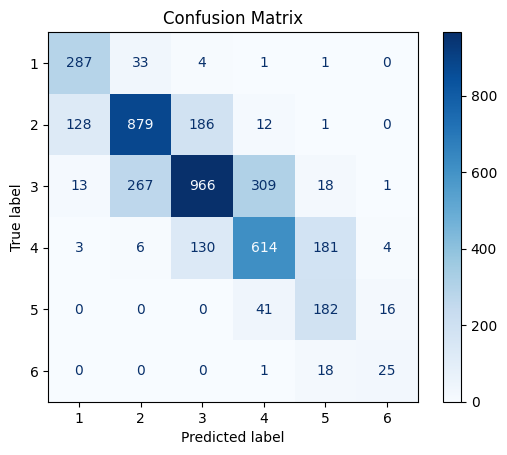

In [121]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(y_true, predictions, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [70]:
# Identifying misclassified samples
misclassified_indices = (y_true != predictions)
misclassified_samples = val_features[misclassified_indices]
misclassified_true_labels = y_true[misclassified_indices]
misclassified_predicted_labels = predictions[misclassified_indices]


In [72]:
# Examining features of misclassified samples
import pandas as pd
misclassified_df = pd.DataFrame(misclassified_samples)
misclassified_df['True_Label'] = misclassified_true_labels
misclassified_df['Predicted_Label'] = misclassified_predicted_labels
# Display the first few rows of the misclassified samples
misclassified_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,True_Label,Predicted_Label
0,0.154565,0.789058,0.098066,0.006899,0.001223,0.001459,0.711378,0.551117,0.326117,0.336264,0.710774,0.364280,0.578822,0.379571,0.457979,0.648876,0.285534,0.558463,0.355019,0.654266,0.495664,0.470325,0.409715,0.615382,0.756452,0.403100,0.537424,0.716282,0.695970,0.429585,0.418334,0.428787,0.614345,0.636310,0.546787,0.490667,0.653500,0.595721,0.557840,0.665729,0.348369,0.411600,0.494662,0.467201,0.454330,0.536900,0.562725,0.508077,0.568207,0.351804,0.545880,0.568026,0.676426,0.372630,0.490684,0.660312,0.503175,0.516968,0.528823,0.432086,0.620853,0.359539,0.763993,0.469601,0.579156,0.622973,0.714989,0.361319,0.422084,0.661798,0.539581,0.458394,0.598660,0.408460,0.510949,0.585148,0.333484,0.615131,0.553839,0.719271,0.502848,0.369842,0.478026,0.496551,0.640751,0.479087,0.554923,0.643825,0.635778,0.397104,0.370333,0.629364,0.492684,0.575384,0.470792,0.336784,0.694520,0.519902,0.662934,0.365165,0.519641,0.655347,0.627554,0.542990,0.486240,0.379550,0.451781,0.705297,0.307407,0.520630,0.495432,0.463755,0.588903,0.550946,0.402814,0.475427,0.504532,0.399133,0.424373,0.449743,0.630914,0.452369,0.670403,0.555791,0.351106,0.356418,0.477078,0.407600,0.414297,0.247855,0.458055,0.413466,0.509847,0.416572,0.587543,0.610309,0.663478,0.575384,0.538347,0.488973,0.407385,0.374577,0.562489,0.286808,0.487029,0.619213,0.555182,0.432556,0.605879,0.379051,0.413432,0.399272,0.378021,0.581670,0.670394,0.528490,0.446187,0.577474,0.562332,0.394143,0.561482,0.373599,0.513875,0.500878,0.406292,0.757863,0.459116,0.580376,0.627590,0.454995,0.506800,0.553433,0.468654,0.561349,0.663356,0.515563,0.602143,0.508258,0.238014,0.629515,0.508479,0.353247,0.329944,0.667603,0.658459,0.524670,0.626845,0.439860,0.335709,0.361744,0.414902,0.431034,0.551564,0.313409,0.563817,0.671700,0.579496,0.604919,0.523531,0.450232,0.343733,0.444462,0.610457,0.522604,0.491281,0.489016,0.532801,0.359304,0.504504,0.377115,0.701813,0.532567,0.552361,0.441113,0.624308,0.421560,0.576431,0.492275,0.566174,0.606172,0.623595,0.449664,0.523544,0.546879,0.495172,0.530910,0.520958,0.499264,0.490580,0.553239,0.554193,0.480669,0.334245,0.548350,0.334874,0.511999,0.555136,0.483739,0.506916,0.470833,0.660255,0.627215,0.721365,0.425614,0.607582,0.615082,0.461793,0.540075,0.572118,0.658934,0.397564,0.480767,0.607018,0.482382,0.566342,0.371956,0.489557,0.579181,0.477254,0.634070,0.387123,0.599745,0.493100,0.380814,0.468151,0.569271,0.507716,0.351927,0.433003,0.542226,0.388034,0.350375,0.489800,0.477826,0.448720,0.526307,0.572595,0.382861,0.587715,0.429598,0.486607,0.485467,0.434657,0.461871,0.615702,0.488262,0.365608,0.327218,0.580469,0.644445,0.326978,0.641254,0.532153,0.419789,0.514875,0.497812,0.449780,0.366521,0.612848,0.425603,0.426855,0.397029,0.481815,0.300900,0.556977,0.639090,0.0,0.0,0.243692,0.243692,0.243692,0.24369

In [80]:
# # Feature importance from LightGBM
# feature_importance = best_model.feature_importance(importance_type='gain')
# feature_names = val_features.columns
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# # Sort features by importance
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print(feature_importance_df)


In [74]:
# Checking class distribution in the true labels
label_counts = pd.Series(y_true).value_counts()
print(label_counts)


3    1574
2    1206
4     938
1     326
5     239
6      44
Name: count, dtype: int64


In [79]:
# from sklearn.model_selection import GridSearchCV
# # Define the hyperparameters to tune
# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'num_leaves': [31, 62, 128],
#     'n_estimators': [50, 100, 200]
# }
# grid_search = GridSearchCV(best_model, param_grid, scoring='', cv=5)
# grid_search.fit(val_features, val_labels)
# print("Best parameters:", grid_search.best_params_)


In [76]:
# Check LightGBM version
import lightgbm as lgb
print(lgb.__version__)


4.3.0


In [78]:
# # Ensure the model is fitted
# if not hasattr(best_model, 'feature_importance_'):
#     best_model.fit(val_features, val_labels)  # Train or re-train the model

# # Retrieve feature importance
# feature_importance = best_model.feature_importance_  # Underscore at the end
# feature_names = val_features.columns

# # Create DataFrame for feature importance
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# print(feature_importance_df)


In [122]:
# Assuming `df` is the original DataFrame and `predictions` is a list/array of predicted labels
# If there's a subset used for predictions, ensure it aligns with the DataFrame
val_df['Predicted_Label'] = predictions


/tmp/ipykernel_19479/2456578638.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val_df['Predicted_Label'] = predictions


In [131]:
print(len(val_features), len(val_df), len(predictions))

4327 4327 4327


In [127]:
val_df.tail()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_vec_158,dense_vec_159,dense_vec_160,dense_vec_161,dense_vec_162,dense_vec_163,dense_vec_164,dense_vec_165,dense_vec_166,dense_vec_167,dense_vec_168,dense_vec_169,dense_vec_170,dense_vec_171,dense_vec_172,dense_vec_173,dense_vec_174,dense_vec_175,dense_vec_176,dense_vec_177,dense_vec_178,dense_vec_179,dense_vec_180,dense_vec_181,dense_vec_182,dense_vec_183,dense_vec_184,dense_vec_185,dense_vec_186,dense_vec_187,dense_vec_188,dense_vec_189,dense_vec_190,dense_vec_191,dense_vec_192,dense_vec_193,dense_vec_194,dense_vec_195,dense_vec_196,dense_vec_197,dense_vec_198,dense_vec_199,dense_vec_200,dense_vec_201,dense_vec_202,dense_vec_203,dense_vec_204,dense_vec_205,dense_vec_206,dense_vec_207,dense_vec_208,dense_vec_209,dense_vec_210,dense_vec_211,dense_vec_212,dense_vec_213,dense_vec_214,dense_vec_215,dense_vec_216,dense_vec_217,dense_vec_218,dense_vec_219,dense_vec_220,dense_vec_221,dense_vec_222,dense_vec_223,dense_vec_224,dense_vec_225,dense_vec_226,dense_vec_227,dense_vec_228,dense_vec_229,dense_vec_230,dense_vec_231,dense_vec_232,dense_vec_233,dense_vec_234,dense_vec_235,dense_vec_236,dense_vec_237,dense_vec_238,dense_vec_239,dense_vec_240,dense_vec_241,dense_vec_242,dense_vec_243,dense_vec_244,dense_vec_245,dense_vec_246,dense_vec_247,dense_vec_248,dense_vec_249,dense_vec_250,dense_vec_251,dense_vec_252,dense_vec_253,dense_vec_254,dense_vec_255,dense_vec_256,dense_vec_257,dense_vec_258,dense_vec_259,dense_vec_260,dense_vec_261,dense_vec_262,dense_vec_263,dense_vec_264,dense_vec_265,dense_vec_266,dense_vec_267,dense_vec_268,dense_vec_269,dense_vec_270,dense_vec_271,dense_vec_272,dense_vec_273,dense_vec_274,dense_vec_275,dense_vec_276,dense_vec_277,dense_vec_278,dense_vec_279,dense_vec_280,dense_vec_281,dense_vec_282,dense_vec_283,dense_vec_284,dense_vec_285,

In [135]:
# merge 'clean_text' column back with val df 

text = val_essays[['essay_id', 'clean_text']]

val_df = val_df.merge(text, on = 'essay_id')

val_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_vec_158,dense_vec_159,dense_vec_160,dense_vec_161,dense_vec_162,dense_vec_163,dense_vec_164,dense_vec_165,dense_vec_166,dense_vec_167,dense_vec_168,dense_vec_169,dense_vec_170,dense_vec_171,dense_vec_172,dense_vec_173,dense_vec_174,dense_vec_175,dense_vec_176,dense_vec_177,dense_vec_178,dense_vec_179,dense_vec_180,dense_vec_181,dense_vec_182,dense_vec_183,dense_vec_184,dense_vec_185,dense_vec_186,dense_vec_187,dense_vec_188,dense_vec_189,dense_vec_190,dense_vec_191,dense_vec_192,dense_vec_193,dense_vec_194,dense_vec_195,dense_vec_196,dense_vec_197,dense_vec_198,dense_vec_199,dense_vec_200,dense_vec_201,dense_vec_202,dense_vec_203,dense_vec_204,dense_vec_205,dense_vec_206,dense_vec_207,dense_vec_208,dense_vec_209,dense_vec_210,dense_vec_211,dense_vec_212,dense_vec_213,dense_vec_214,dense_vec_215,dense_vec_216,dense_vec_217,dense_vec_218,dense_vec_219,dense_vec_220,dense_vec_221,dense_vec_222,dense_vec_223,dense_vec_224,dense_vec_225,dense_vec_226,dense_vec_227,dense_vec_228,dense_vec_229,dense_vec_230,dense_vec_231,dense_vec_232,dense_vec_233,dense_vec_234,dense_vec_235,dense_vec_236,dense_vec_237,dense_vec_238,dense_vec_239,dense_vec_240,dense_vec_241,dense_vec_242,dense_vec_243,dense_vec_244,dense_vec_245,dense_vec_246,dense_vec_247,dense_vec_248,dense_vec_249,dense_vec_250,dense_vec_251,dense_vec_252,dense_vec_253,dense_vec_254,dense_vec_255,dense_vec_256,dense_vec_257,dense_vec_258,dense_vec_259,dense_vec_260,dense_vec_261,dense_vec_262,dense_vec_263,dense_vec_264,dense_vec_265,dense_vec_266,dense_vec_267,dense_vec_268,dense_vec_269,dense_vec_270,dense_vec_271,dense_vec_272,dense_vec_273,dense_vec_274,dense_vec_275,dense_vec_276,dense_vec_277,dense_vec_278,dense_vec_279,dense_vec_280,dense_vec_281,dense_vec_282,dense_vec_283,dense_vec_284,dense_vec_285,

In [136]:
# Assuming `df` has the original labels in a column named 'True_Label'
misclassified_samples = val_df[val_df['score'] != val_df['Predicted_Label']]

# Display misclassified samples
print(misclassified_samples[['score', 'Predicted_Label', 'clean_text']][:15])


    score  Predicted_Label                                         clean_text
3       2                1  the challenge of exploring venus this storie i...
7       2                1  in the text the author uses facts that people ...
8       2                1  the challege of exploring venus is not a great...
10      2                3  limiting car use is a great way clean up green...
15      1                2  the author suggets that studying venus is a wo...
18      3                4  the use of the facial action coding system in ...
19      4                5  in the challenge of exploring venus the debate...
20      1                3  the face was dicovered on may twenty four two ...
24      4                5  driverless cars are the future google has had ...
27      4                3  in the article the challenge of exploring venu...
28      4                5  fellow citizens there are many reasons why lim...
32      2                3  the challenge of exploring venus is 

In [137]:
# Example: Analyze original text of misclassified samples
misclassified_text = misclassified_samples['clean_text']  # Assuming 'Text' is the original text data
print(misclassified_text.head())


3     the challenge of exploring venus this storie i...
7     in the text the author uses facts that people ...
8     the challege of exploring venus is not a great...
10    limiting car use is a great way clean up green...
15    the author suggets that studying venus is a wo...
Name: clean_text, dtype: object


In [ ]:
# load tf model





